### Importing the libraries

In [1]:
# operational libraries
import numpy as np
import pandas as pd

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# general sklearn libraries
from sklearn.model_selection import train_test_split

### Import the dataset

In [2]:
dataset = pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')

dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Variable bifurcation:

* Pregnancies: Number of times pregnant

* Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test

* BloodPressure: Diastolic blood pressure (mm Hg)

* SkinThikness: Triceps skin fold thickness (mm)

* Insulin: 2-Hour serum insulin (mu U/ml)

* BMI: Body mass index (weight in kg/(height in m)^2)4

* DiabetesPedigreeFunction: Diabetes pedigree function

* Age: age in years

* Outcome: target class variable

### Splitting the dataset

In [3]:
x_train, x_test, y_train, y_test = train_test_split(dataset.drop('Outcome', axis=1),
                                                   dataset['Outcome'],
                                                   test_size=0.3,
                                                   random_state=0)

x_train.shape, x_test.shape

((537, 8), (231, 8))

### Data Analysis

**variable nature analysis**

In [4]:
x_train.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object

In [5]:
# numerical variables

discrete_variables = [var for var in x_train.columns if x_train[var].dtype != 'O' and x_train[var].nunique() < 10]
continuous_variables = [var for var in x_train.columns if var not in discrete_variables and x_train[var].dtype != 'O']


In [6]:
discrete_variables

[]

In [7]:
continuous_variables

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

**Missing Values**

In [8]:
x_train.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [9]:
x_test.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

**Distribution of variables**

In [10]:
# this function will help us figuring out the distribution and the outliers the independent variables have
def diagnostic_plot(df,var):
    
    fig = plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    df[var].plot(kind='hist',bins=50)
    plt.title('Histogram')
    plt.xlabel(var)
    
    plt.subplot(1,3,2)
    stats.probplot(df[var], dist='norm', plot=plt)
    plt.ylabel('RM quanriles')
    
    plt.subplot(1,3,3)
    sns.boxplot(y=df[var])
    plt.title('Boxplot')
    
    plt.show()

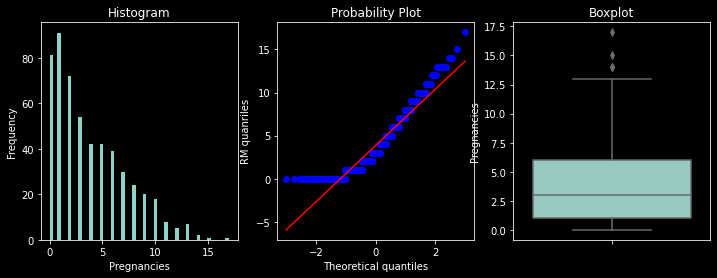

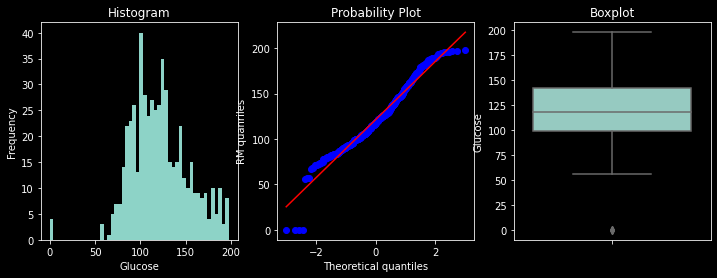

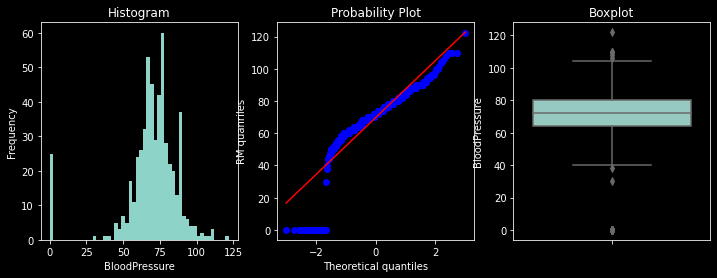

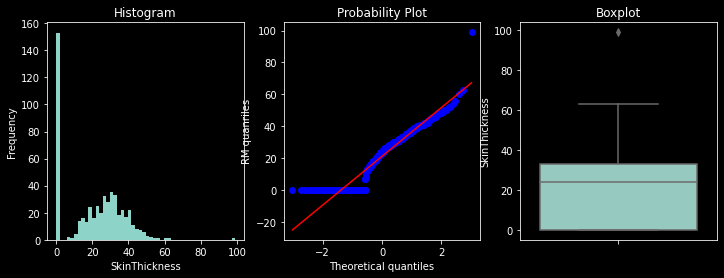

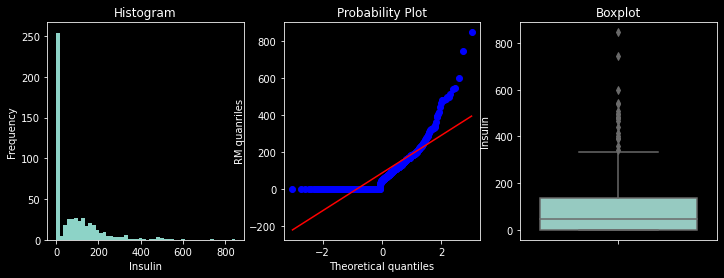

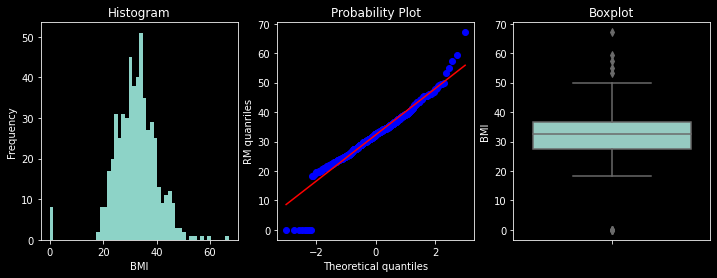

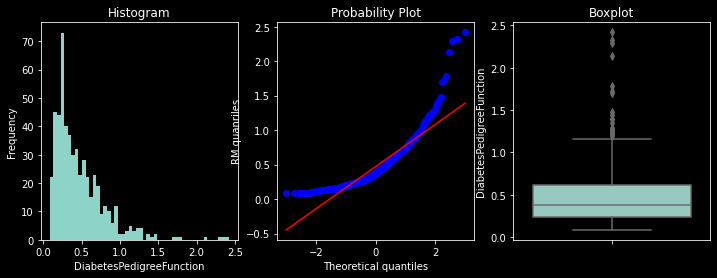

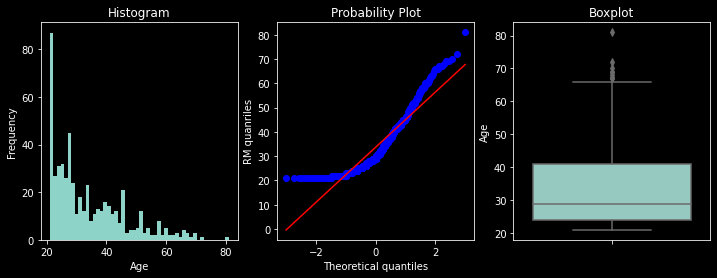

In [11]:
plt.style.use('dark_background')

for var in continuous_variables:
    diagnostic_plot(x_train, var)

We can see that, independent variables are highly skewed and the variables also have outliers. We can use transformation method to make the data gaussian after removing the outliers.

**Multicolinearity**

<AxesSubplot:>

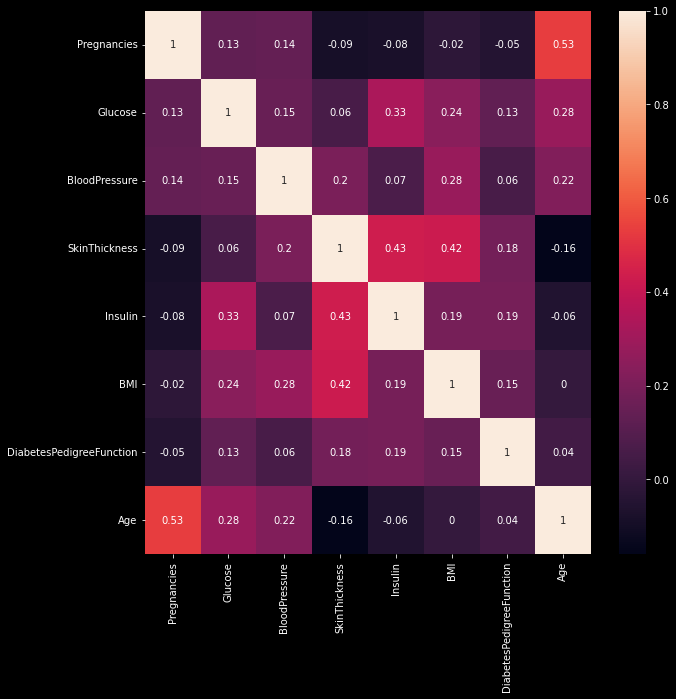

In [12]:
# to determine co-linearity, we evaluate the correlation of independent variables

# we calculate the correlations using pandas corr()
# and we round the values to 2 decimals
correlation_matrix = np.round(x_train.corr(),2)

# plot the correlation matric using seaborn
# we use annot = true to print the correlation values

fig = plt.figure(figsize=(10,10))
sns.heatmap(data=correlation_matrix, annot=True)

On the x and y axis of the heatmap, we see the variables of the dataframe. Within each square, the correlation value between those 2 variables is indicated. For the variables Age and Pregnancies, the correlation is 0.53. These variables are positively correlated. On the contrary SkinThickness and age shows a correlation value of -0.16.

Let's see how they look on a scatter plot.

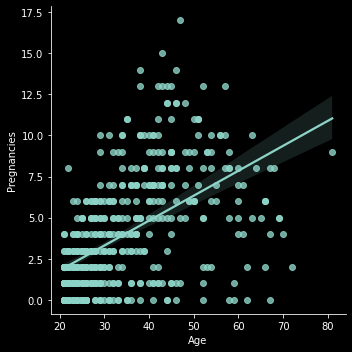

In [13]:
#  correlation between Age and Pregnancies

sns.lmplot(x='Age', y='Pregnancies', data=x_train)
plt.show()

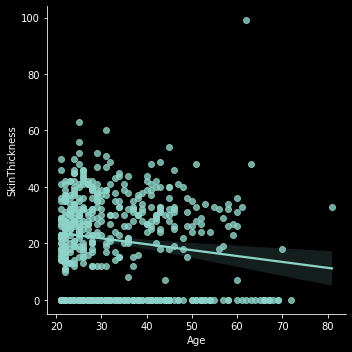

In [14]:
# correlation between Age and SkinThickness
sns.lmplot(x='Age', y= 'SkinThickness', data=x_train)
plt.show()

**Feature Magnitude**

In [15]:
x_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000,537.00000,537.000000
mean,3.854749,121.543762,69.666667,21.031657,84.901304,32.255121,0.47132,33.670391
std,3.405075,32.242413,19.464823,16.030548,118.601111,8.034497,0.33441,12.003471
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.08400,21.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.500000,0.24000,24.000000
50%,3.000000,118.000000,72.000000,24.000000,45.000000,32.400000,0.37800,29.000000
75%,6.000000,142.000000,80.000000,33.000000,135.000000,36.800000,0.61300,41.000000
max,17.000000,198.000000,122.000000,99.000000,846.000000,67.100000,2.42000,81.000000


We can see that the independent variables have different range and scale.

### Feature Engineering

**Discretization**

In [16]:
!pip install feature_engine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 495.7 kB/s eta 0:00:00


In [17]:
from feature_engine.discretisation import EqualWidthDiscretiser

In [18]:
disc = EqualWidthDiscretiser(variables=continuous_variables,bins=5, return_object=True)

disc.fit(x_train)
x_train = disc.transform(x_train)
x_test = disc.transform(x_test)

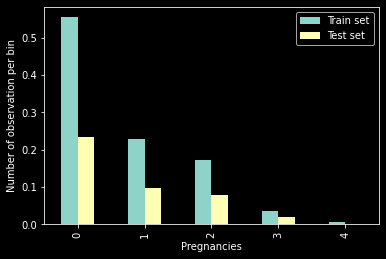

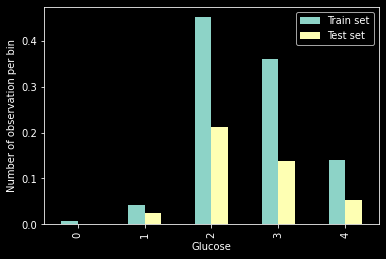

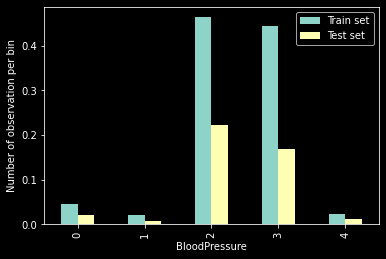

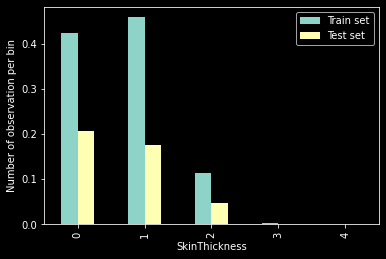

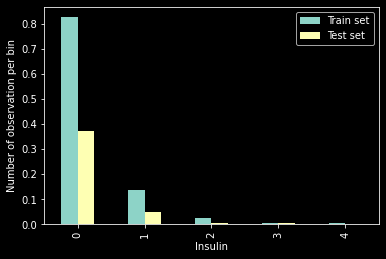

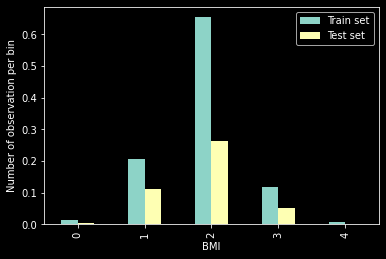

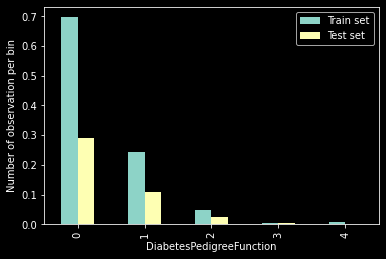

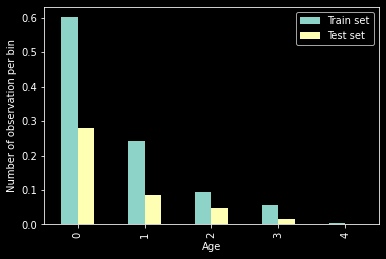

In [19]:
for var in continuous_variables:
    t1 = x_train.groupby([var])[var].count()/ len(x_train)
    t2 = x_test.groupby([var])[var].count()/ len(x_train)
    
    tmp = pd.concat([t1,t2], axis=1)
    tmp.columns = ['Train set','Test set']
    tmp.plot(kind='bar')
    plt.ylabel('Number of observation per bin')
    plt.show()

**Encoding Numerical Variables**

In [20]:
from feature_engine.encoding import OrdinalEncoder

In [21]:
encoder = OrdinalEncoder(encoding_method='ordered',variables=continuous_variables)

encoder.fit(x_train,y_train)

x_train = encoder.transform(x_train)
x_test = encoder.transform(x_test)

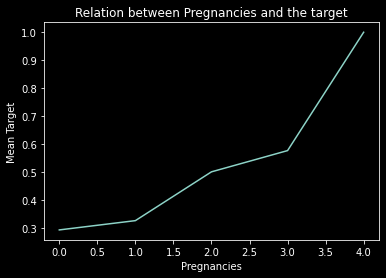

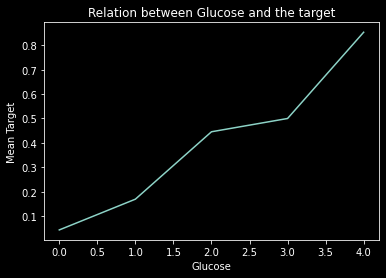

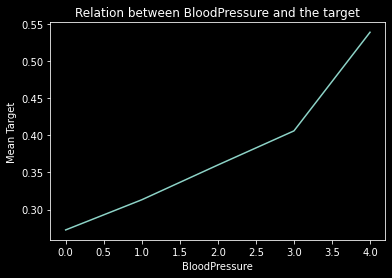

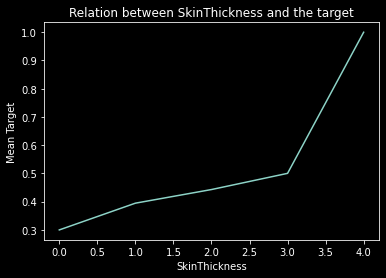

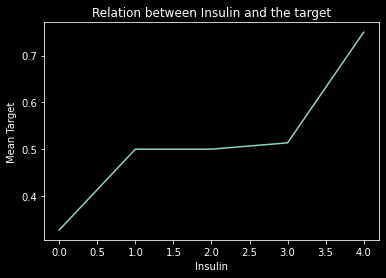

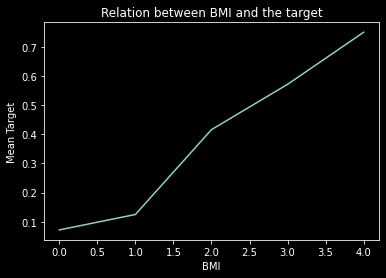

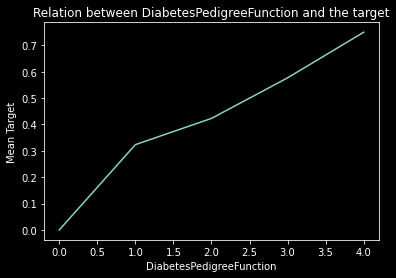

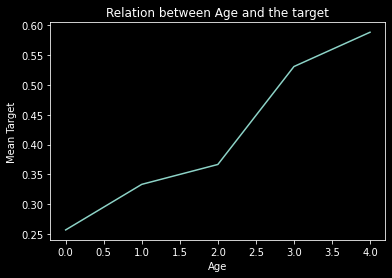

In [22]:
tmp_df = pd.concat([x_train,y_train],axis=1)
for var in continuous_variables:
    fig = plt.figure()
    fig = tmp_df.groupby([var])['Outcome'].mean().plot()
    fig.set_title('Relation between {} and the target'.format(var))
    fig.set_xlabel(var)
    fig.set_ylabel('Mean Target')
    plt.show()

**Feature Scaling**

In [23]:
from sklearn.preprocessing import RobustScaler

In [24]:
scaler = RobustScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

**Model Building**

In [25]:
# importing model
from sklearn.neighbors import KNeighborsClassifier

# importing Gridsearch and cross validation score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report

In [26]:
knn_bs = KNeighborsClassifier(metric='euclidean')
knn_bs.fit(x_train,y_train)
y_knn_bs = knn_bs.predict(x_test)

In [27]:
print('MSE: ', mean_squared_error(y_test, y_knn_bs))
print('\n')
print('RMSE: ', np.sqrt(mean_squared_error(y_test,y_knn_bs)))
print('\n')
print('Accuracy Score: ', accuracy_score(y_test, y_knn_bs))

MSE:  0.22943722943722944


RMSE:  0.4789960641145493


Accuracy Score:  0.7705627705627706


In [28]:
knn = KNeighborsClassifier()
k_range = list(range(1, 31))
param_grid = dict(n_neighbors=k_range, weights=['uniform', 'distance'],
                 metric=['minkowski','euclidean'])
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')
grid.fit(x_train,y_train)
best_accuracy = grid.best_score_
best_parameters = grid.best_params_
print('Best Accuracy: {:.2f}%'.format(best_accuracy*100))
print('Best Parameters:', best_parameters)

Best Accuracy: 76.35%
Best Parameters: {'metric': 'minkowski', 'n_neighbors': 15, 'weights': 'uniform'}


In [29]:
knn_tuned = KNeighborsClassifier(n_neighbors=15, metric='minkowski',
                                weights='uniform')
knn_tuned.fit(x_train,y_train)
y_knn_tuned = knn_tuned.predict(x_test)

In [30]:
print('MSE: ', mean_squared_error(y_test, y_knn_tuned))
print('\n')
print('RMSE: ', np.sqrt(mean_squared_error(y_test,y_knn_tuned)))
print('\n')
print('Accuracy Score: ', accuracy_score(y_test, y_knn_tuned))

MSE:  0.21212121212121213


RMSE:  0.4605661864718383


Accuracy Score:  0.7878787878787878


In [31]:
np.concatenate((y_test.values.reshape(len(y_test),1),y_knn_tuned.reshape(len(y_knn_tuned),1)),1)

array([[1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [1, 1],
       [1,

In [32]:
accuries = cross_val_score(knn_tuned, x_train,y_train, cv=10)
print('Accuracy: {:.2f} %'.format(accuries.mean()*100))
print('Standard Deviation: {:.2f} %'.format(accuries.std()*100))

Accuracy: 76.35 %
Standard Deviation: 4.87 %


In [33]:
print(confusion_matrix(y_test, y_knn_tuned))
print('\n')
print(classification_report(y_test, y_knn_tuned))

[[141  16]
 [ 33  41]]


              precision    recall  f1-score   support

           0       0.81      0.90      0.85       157
           1       0.72      0.55      0.63        74

    accuracy                           0.79       231
   macro avg       0.76      0.73      0.74       231
weighted avg       0.78      0.79      0.78       231

